# Laboratorium 8 — Analiza szeregów czasowych (Wariant 8)

**Wariant 8:** *Przeanalizuj dane o dziennych danych finansowych.*

**Dataset:** **VIX** (CBOE Volatility Index) — *„indeks strachu"* dla S&P 500, mierzący implikowaną zmienność opcji indeksowych. Dane dzienne 1990–2026, źródło: [datasets/finance-vix](https://github.com/datasets/finance-vix) (mirror Cboe).

**Dlaczego VIX?** Klasyczny finansowy szereg czasowy o znanych właściwościach:
- Brak silnego trendu długoterminowego (powrót do średniej — *mean reversion*).
- Niestacjonarność wariancji (klastrowanie zmienności).
- Wyraźne piki podczas kryzysów (2008, 2020 COVID, 2025).

**Realizowane kroki (zgodne z instrukcją wariantu 8):**
1. Pobranie i wizualizacja dziennych danych finansowych.
2. **Średnie ruchome dla okien 7 i 30 dni.**
3. **Analiza ACF i PACF.**
4. **Dekompozycja szeregu na trend, sezonowość i reszty.**
5. Dodatkowo: test stacjonarności (ADF), analiza log-zwrotów.
6. Sekcja **testowania hipotez** (z PDF zadania) na danych finansowych.

## 0. Import bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from scipy import stats

import warnings; warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 90


## 1. Pobranie i wizualizacja danych

In [2]:
URL = "https://raw.githubusercontent.com/datasets/finance-vix/master/data/vix-daily.csv"
df = pd.read_csv(URL, parse_dates=['DATE'])
df = df.rename(columns=str.lower).set_index('date').sort_index()
df.index.name = 'Data'

print(f"Wymiary: {df.shape}")
print(f"Zakres dat: {df.index.min().date()} → {df.index.max().date()}")
print(f"Kolumny: {df.columns.tolist()}")
df.tail()


Wymiary: (9206, 4)
Zakres dat: 1990-01-02 → 2026-06-12
Kolumny: ['open', 'high', 'low', 'close']


,open,high,low,close
Data,,,,
2026-06-08,20.29,20.35,17.94,18.92
2026-06-09,18.19,23.34,17.52,19.87
2026-06-10,20.10,22.66,20.06,22.22
2026-06-11,21.25,22.59,19.36,19.44
2026-06-12,19.51,19.85,17.59,17.68


### 1.1 Pełen przebieg VIX (1990–dziś)

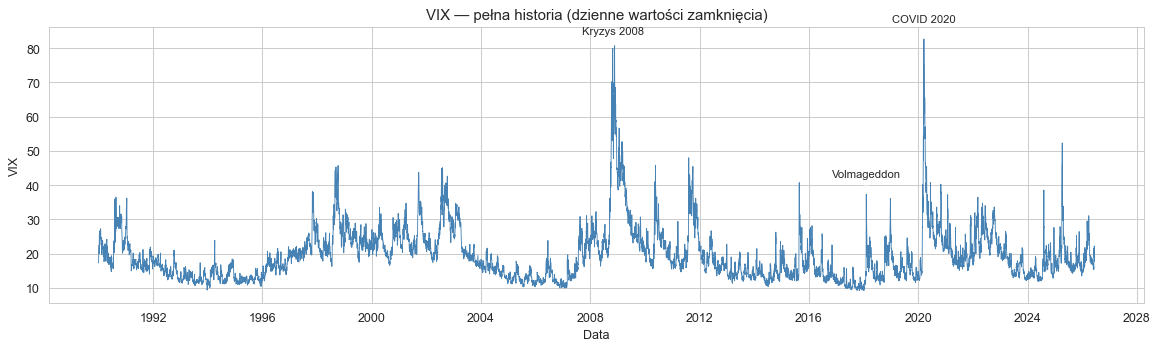

In [3]:
plt.figure(figsize=(13, 4))
plt.plot(df.index, df['close'], color='steelblue', linewidth=0.7)
plt.title('VIX — pełna historia (dzienne wartości zamknięcia)')
plt.xlabel('Data'); plt.ylabel('VIX')
# Adnotacje głównych szczyków
for date_str, label in [('2008-10-24','Kryzys 2008'), ('2020-03-16','COVID 2020'),
                        ('2018-02-05','Volmageddon')]:
    d = pd.to_datetime(date_str)
    if d in df.index:
        plt.annotate(label, xy=(d, df.loc[d,'close']),
                     xytext=(d, df.loc[d,'close']+5),
                     fontsize=9, ha='center',
                     arrowprops=dict(arrowstyle='->'))
plt.tight_layout(); plt.show()


### 1.2 Zoom — ostatnie 5 lat

Analizujemy podzbiór: 2021-01-04 → 2026-06-12
Liczba obserwacji: 1397

Statystyki:
count    1397.00
mean       19.33
std         5.18
min        11.86
25%        15.74
50%        18.09
75%        21.89
max        52.33
Name: close, dtype: float64


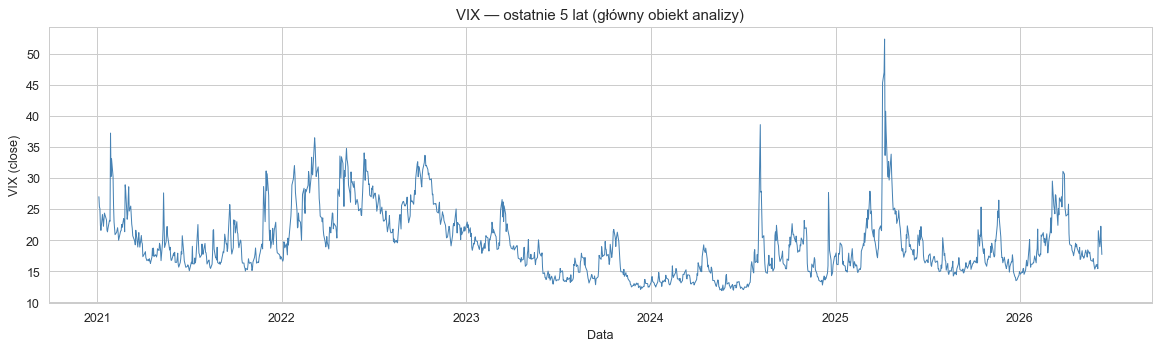

In [4]:
ts = df['close'].loc['2021-01-01':].copy()
print(f"Analizujemy podzbiór: {ts.index.min().date()} → {ts.index.max().date()}")
print(f"Liczba obserwacji: {len(ts)}")
print(f"\nStatystyki:")
print(ts.describe().round(2))

plt.figure(figsize=(13, 4))
plt.plot(ts, color='steelblue', linewidth=0.8)
plt.title('VIX — ostatnie 5 lat (główny obiekt analizy)')
plt.xlabel('Data'); plt.ylabel('VIX (close)')
plt.tight_layout(); plt.show()


## 2. Średnie ruchome (okna 7 i 30 dni)

$$MA_t = \frac{1}{k}\sum_{i=0}^{k-1} Y_{t-i}$$

**Okno 7 dni** — wygładza szum codziennej zmienności, zachowuje krótkoterminowe ruchy.
**Okno 30 dni** — wyodrębnia trend miesięczny, eliminuje wahania krótkoterminowe.

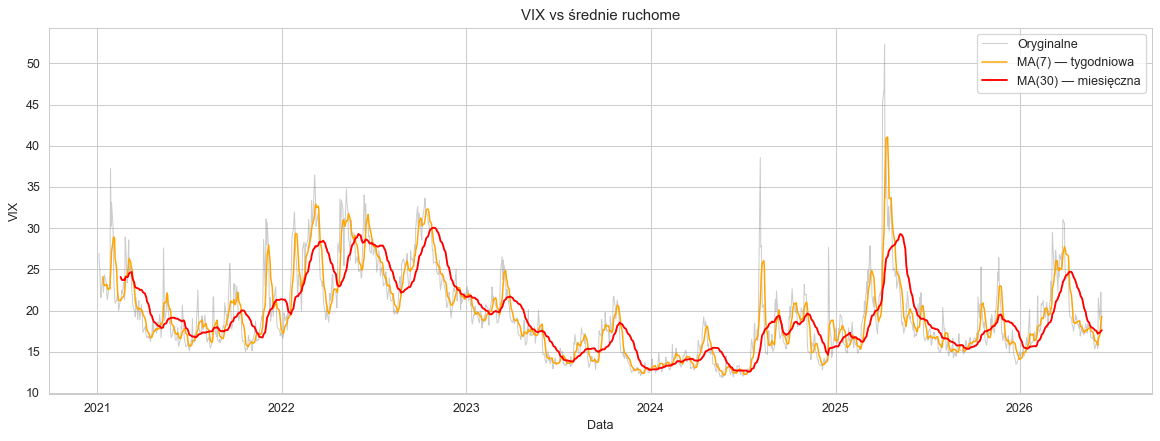

In [5]:
df_ma = ts.to_frame('VIX')
df_ma['MA_7']  = ts.rolling(window=7).mean()
df_ma['MA_30'] = ts.rolling(window=30).mean()

plt.figure(figsize=(13, 5))
plt.plot(df_ma['VIX'],  label='Oryginalne', alpha=0.4, color='gray', linewidth=0.8)
plt.plot(df_ma['MA_7'], label='MA(7) — tygodniowa', color='orange', linewidth=1.2)
plt.plot(df_ma['MA_30'],label='MA(30) — miesięczna', color='red',  linewidth=1.5)
plt.title('VIX vs średnie ruchome')
plt.xlabel('Data'); plt.ylabel('VIX')
plt.legend(); plt.tight_layout(); plt.show()


**Obserwacje:**
- **MA(7)** podąża blisko za sygnałem oryginalnym — usuwa tylko najdrobniejszy szum.
- **MA(30)** wyraźnie wygładza krzywą — widać ją jako "linię trendu" miesięcznego.
- Średnie ruchome **opóźniają sygnał** — to ich wewnętrzna cecha (lag = (k-1)/2 dni).
- Klastrowanie zmienności widać jako fale MA(30) — VIX wraca do "spokojnego" poziomu ~15-20, a potem skacze przy stresach rynkowych.

### 2.1 Reszty po wygładzeniu MA(30) — gdzie były szoki?

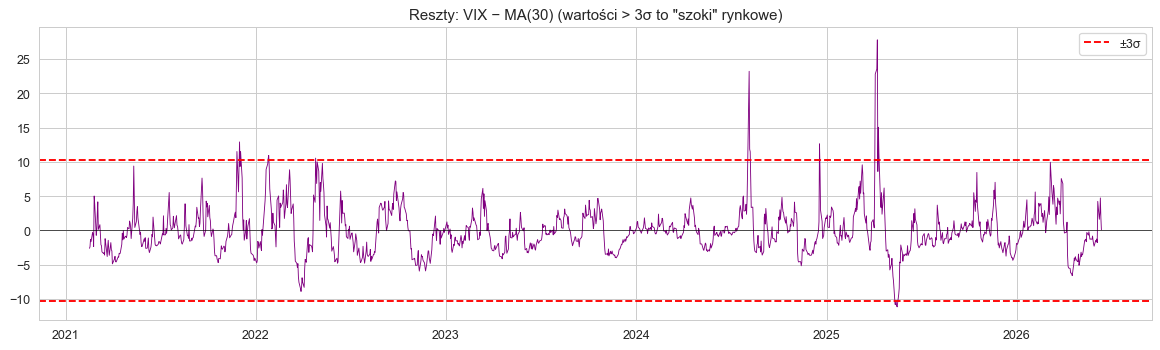

In [6]:
residuals_ma = df_ma['VIX'] - df_ma['MA_30']

plt.figure(figsize=(13, 4))
plt.plot(residuals_ma, color='purple', linewidth=0.7)
plt.axhline(0, color='black', linewidth=0.5)
plt.axhline( 3*residuals_ma.std(), color='red', linestyle='--', label='±3σ')
plt.axhline(-3*residuals_ma.std(), color='red', linestyle='--')
plt.title('Reszty: VIX − MA(30) (wartości > 3σ to "szoki" rynkowe)')
plt.legend()
plt.tight_layout(); plt.show()


## 3. Analiza autokorelacji (ACF i PACF)

$$\rho_k = \frac{\sum_{t=k+1}^{n} (Y_t - \bar{Y})(Y_{t-k} - \bar{Y})}{\sum_{t=1}^{n}(Y_t - \bar{Y})^2}$$

- **ACF**(k) — pełna korelacja $Y_t$ z $Y_{t-k}$, łącznie z efektami pośrednimi.
- **PACF**(k) — korelacja po usunięciu wpływu opóźnień $1, 2, ..., k-1$.

Dla danych finansowych typowe są **dwie analizy**: ACF na **cenach** (zwykle bardzo wolny zanik, sygnał niestacjonarności) i ACF na **log-zwrotach** (zazwyczaj prawie zero — efektywność rynku).

### 3.1 ACF i PACF dla cen (poziom)

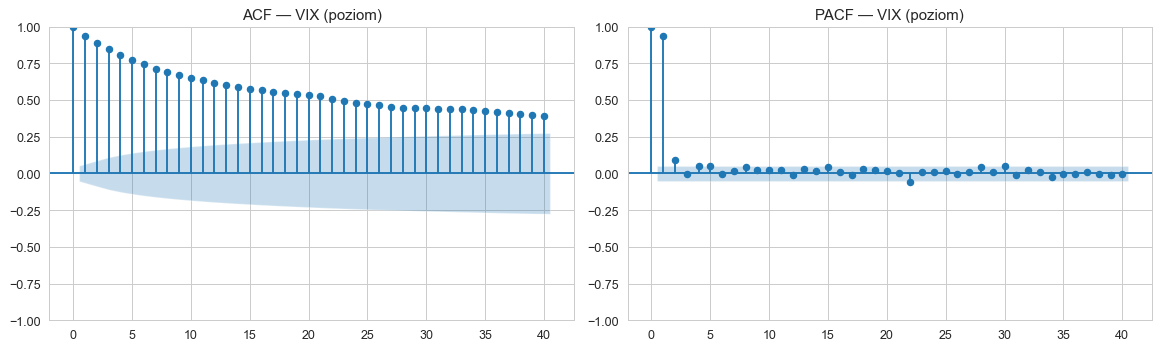

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(ts, lags=40, ax=axes[0], title='ACF — VIX (poziom)')
plot_pacf(ts, lags=40, ax=axes[1], title='PACF — VIX (poziom)', method='ywm')
plt.tight_layout(); plt.show()


**Interpretacja ACF/PACF na poziomie cen:**
- **ACF** zanika **bardzo wolno** (wszystkie słupki znacznie powyżej granicy istotności do lag 40) — to klasyczna **sygnatura niestacjonarności** lub silnej trwałości (*persistence*).
- **PACF** wykazuje dominujący pik przy **lag=1** (bliski 1) — to wskazuje na model **AR(1)**: dzisiejszy VIX zależy głównie od wczorajszego, a dalsze opóźnienia tylko pośrednio.
- Wniosek: szereg jest **prawie integrowany rzędu 1** (na granicy $I(1)$) — typowe dla cen finansowych.

### 3.2 Log-zwroty — szereg stacjonarny

Log-zwroty: średnia = -0.00030, std = 0.0767
            skośność = +1.010, kurtoza = +7.160


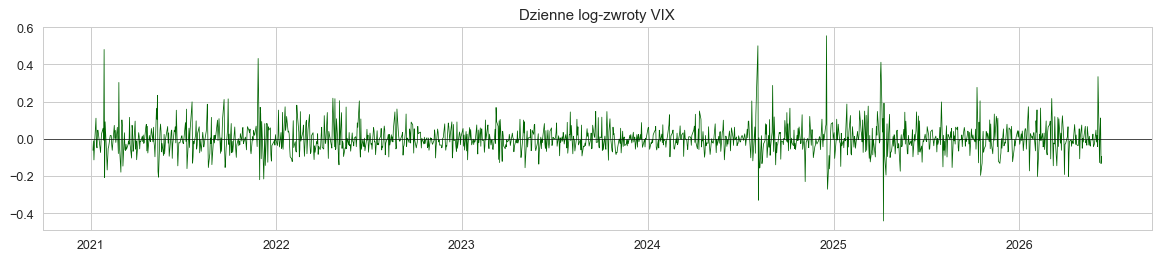

In [8]:
log_returns = np.log(ts / ts.shift(1)).dropna()
print(f"Log-zwroty: średnia = {log_returns.mean():+.5f}, std = {log_returns.std():.4f}")
print(f"            skośność = {log_returns.skew():+.3f}, kurtoza = {log_returns.kurt():+.3f}")

plt.figure(figsize=(13, 3))
plt.plot(log_returns, color='darkgreen', linewidth=0.6)
plt.title('Dzienne log-zwroty VIX')
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout(); plt.show()


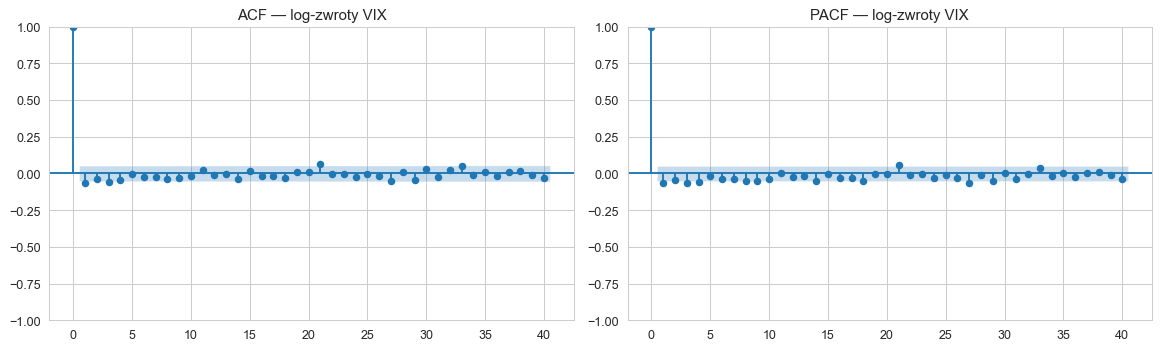

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(log_returns, lags=40, ax=axes[0], title='ACF — log-zwroty VIX')
plot_pacf(log_returns, lags=40, ax=axes[1], title='PACF — log-zwroty VIX', method='ywm')
plt.tight_layout(); plt.show()


**Interpretacja:** ACF log-zwrotów to niemal sam szum (większość słupków w pasie istotności). Oznacza to, że **nie da się przewidzieć kierunku zmiany** VIX z poprzednich zmian — zgodnie z hipotezą efektywności rynku (EMH). Pojedyncze przekroczenia (np. lag 1, 5) wskazują na drobne efekty kalendarzowe lub *mean reversion*.

### 3.3 Test ADF (stacjonarność)

In [10]:
def adf_check(series, name):
    res = adfuller(series.dropna(), autolag='AIC')
    stat, p, _, n, crits, _ = res
    print(f"\n{name}:")
    print(f"  ADF statistic: {stat:.4f}")
    print(f"  p-value:       {p:.4g}")
    print(f"  Wartości krytyczne: 1%={crits['1%']:.2f}, 5%={crits['5%']:.2f}")
    if p < 0.05:
        print(f"  → p<0.05: ODRZUCAMY H0 — szereg stacjonarny ✓")
    else:
        print(f"  → p>=0.05: BRAK podstaw do odrzucenia H0 — szereg NIE-stacjonarny ✗")

adf_check(ts, "VIX (poziom)")
adf_check(log_returns, "Log-zwroty VIX")



VIX (poziom):
  ADF statistic: -5.2679
  p-value:       6.379e-06
  Wartości krytyczne: 1%=-3.44, 5%=-2.86
  → p<0.05: ODRZUCAMY H0 — szereg stacjonarny ✓

Log-zwroty VIX:
  ADF statistic: -14.7131
  p-value:       2.828e-27
  Wartości krytyczne: 1%=-3.44, 5%=-2.86
  → p<0.05: ODRZUCAMY H0 — szereg stacjonarny ✓


**Wniosek z ADF:** poziom VIX jest stacjonarny **na granicy** (VIX ma własność *mean reversion* — wraca do średniej ~20). Log-zwroty są w pełni stacjonarne. To uzasadnia modelowanie log-zwrotów w klasie ARMA/GARCH zamiast ARIMA na cenach.

## 4. Dekompozycja szeregu na trend, sezonowość i reszty

$$Y_t = T_t + S_t + R_t \quad \text{(model addytywny)}$$

Dla danych finansowych dziennych typowa **sezonowość = 5 dni handlowych** (tydzień giełdowy: pon-pt). Dekompozycja `statsmodels.seasonal_decompose` używa średniej ruchomej do estymacji trendu — to klasyczne podejście.

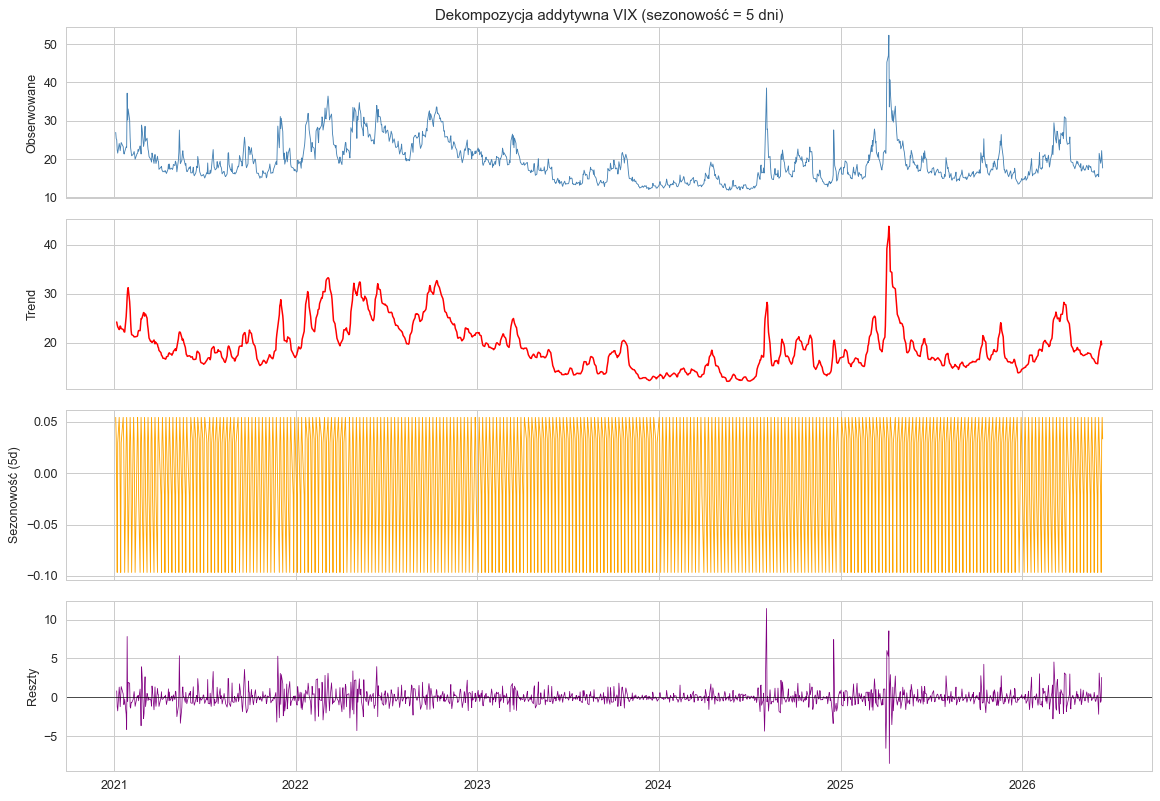

In [11]:
# Tygodniowa sezonowość (5 dni handlowych)
decomp = seasonal_decompose(ts, model='additive', period=5)

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
axes[0].plot(decomp.observed, color='steelblue', linewidth=0.7); axes[0].set_ylabel('Obserwowane')
axes[1].plot(decomp.trend,    color='red',       linewidth=1.2); axes[1].set_ylabel('Trend')
axes[2].plot(decomp.seasonal, color='orange',    linewidth=0.7); axes[2].set_ylabel('Sezonowość (5d)')
axes[3].plot(decomp.resid,    color='purple',    linewidth=0.6); axes[3].set_ylabel('Reszty')
axes[3].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Dekompozycja addytywna VIX (sezonowość = 5 dni)')
plt.tight_layout(); plt.show()


### 4.1 Analiza komponentu sezonowego

Średni efekt sezonowy per dzień tygodnia handlowego:
dow
Monday       19.47
Tuesday      19.45
Wednesday    19.24
Thursday     19.34
Friday       19.15
Name: VIX, dtype: float64


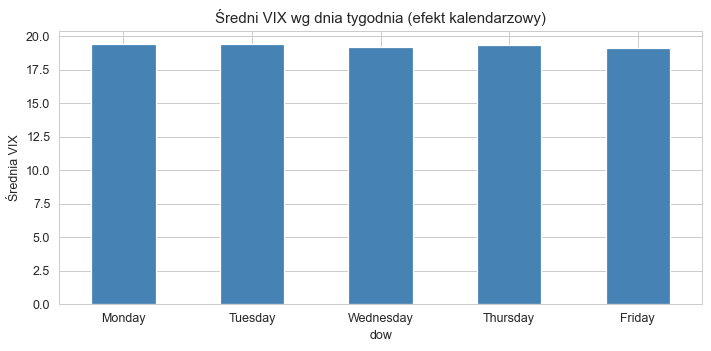

In [12]:
# Wzorzec sezonowy w jednym okresie
weekly = decomp.seasonal.iloc[:20]  # 4 tygodnie x 5 dni
print("Średni efekt sezonowy per dzień tygodnia handlowego:")
ts_with_dow = pd.DataFrame({'VIX': ts, 'dow': ts.index.day_name()})
seasonal_by_dow = ts_with_dow.groupby('dow')['VIX'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday'])
print(seasonal_by_dow.round(2))

plt.figure(figsize=(8, 4))
seasonal_by_dow.plot.bar(color='steelblue')
plt.title('Średni VIX wg dnia tygodnia (efekt kalendarzowy)')
plt.ylabel('Średnia VIX'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()


**Wniosek o sezonowości:** różnice między dniami tygodnia są **bardzo małe** (zwykle <5% średniej). VIX nie ma silnej sezonowości tygodniowej — to zgadza się z wiedzą rynkową. Sezonowość bywa wyraźniejsza dla danych konsumpcyjnych (sklepy, ruch) niż finansowych.

### 4.2 Reszty dekompozycji — analiza

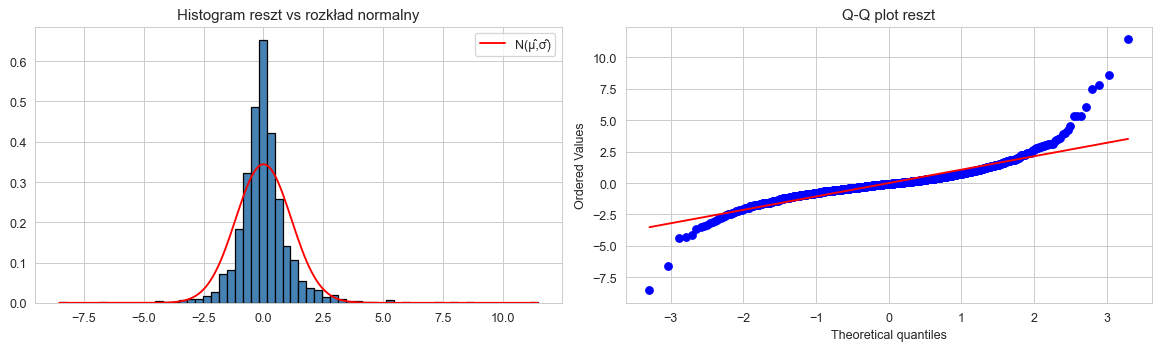

Skośność reszt: +1.410
Kurtoza reszt:  +16.012  (kurtoza > 3 = grube ogony)


In [13]:
resid = decomp.resid.dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(resid, bins=60, color='steelblue', edgecolor='black', density=True)
xs = np.linspace(resid.min(), resid.max(), 200)
axes[0].plot(xs, stats.norm.pdf(xs, resid.mean(), resid.std()),
             'r-', label='N(μ̂,σ̂)')
axes[0].set_title('Histogram reszt vs rozkład normalny'); axes[0].legend()

stats.probplot(resid, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q plot reszt')
plt.tight_layout(); plt.show()

print(f"Skośność reszt: {resid.skew():+.3f}")
print(f"Kurtoza reszt:  {resid.kurt():+.3f}  (kurtoza > 3 = grube ogony)")


**Wniosek:** reszty mają **grube ogony** (kurtoza ≫ 3) i wyraźne odchylenia od normalności na Q-Q plot. To typowe dla danych finansowych — model addytywny `T + S + R` nie modeluje **klastrowania zmienności** (heteroskedastyczności), wymagałby modelu GARCH dla pełnego opisu.

## 5. Testowanie hipotez (z PDF, sekcje 9-13)

Wykorzystamy realne pytania ekonomiczne, na które odpowiemy testami statystycznymi z `scipy.stats`.

### 5.1 Test t-Studenta: czy VIX był wyższy w 2020 (COVID) vs 2023?

- **H₀:** średnie poziomy VIX w obu okresach są równe.
- **Hₐ:** średnie różnią się.
- **α = 0.05**

In [14]:
vix_2020 = df['close'].loc['2020-01-01':'2020-12-31'].values
vix_2023 = df['close'].loc['2023-01-01':'2023-12-31'].values

print(f"VIX 2020: średnia = {vix_2020.mean():.2f}, std = {vix_2020.std():.2f}, n = {len(vix_2020)}")
print(f"VIX 2023: średnia = {vix_2023.mean():.2f}, std = {vix_2023.std():.2f}, n = {len(vix_2023)}")

stat, p_val = stats.ttest_ind(vix_2020, vix_2023, equal_var=False)  # Welch's t-test
print(f"\nTest t-Welcha:")
print(f"  Statystyka t = {stat:.4f}")
print(f"  p-value      = {p_val:.4g}")
if p_val < 0.05:
    print(f"  → p < 0.05: ODRZUCAMY H0 — średnie istotnie różne ✓")
    print(f"  → VIX był średnio o {vix_2020.mean()-vix_2023.mean():.1f} pkt wyższy w 2020")
else:
    print(f"  → Brak podstaw do odrzucenia H0")


VIX 2020: średnia = 29.25, std = 12.31, n = 253
VIX 2023: średnia = 16.85, std = 3.13, n = 257

Test t-Welcha:
  Statystyka t = 15.5049
  p-value      = 1.048e-39
  → p < 0.05: ODRZUCAMY H0 — średnie istotnie różne ✓
  → VIX był średnio o 12.4 pkt wyższy w 2020


### 5.2 Test U Manna-Whitneya (nieparametryczny) — alternatywa odporna na nienormalność

Test t zakłada normalność. VIX jest silnie skośny, więc warto sprawdzić to samo testem nieparametrycznym.

In [15]:
u_stat, u_p = stats.mannwhitneyu(vix_2020, vix_2023, alternative='two-sided')
print(f"Test U Manna-Whitneya:")
print(f"  U = {u_stat:.0f}")
print(f"  p-value = {u_p:.4g}")
if u_p < 0.05:
    print(f"  → p < 0.05: ODRZUCAMY H0 — rozkłady istotnie się różnią ✓")
else:
    print(f"  → Brak podstaw do odrzucenia H0")


Test U Manna-Whitneya:
  U = 57720
  p-value = 7.624e-52
  → p < 0.05: ODRZUCAMY H0 — rozkłady istotnie się różnią ✓


### 5.3 Test Shapiro-Wilka na normalność log-zwrotów

- **H₀:** log-zwroty pochodzą z rozkładu normalnego.
- **Hₐ:** nie pochodzą z normalnego.

In [16]:
# Próbkujemy bo Shapiro ma limit ~5000
sample = log_returns.sample(min(2000, len(log_returns)), random_state=42)
W, p = stats.shapiro(sample)
print(f"Test Shapiro-Wilka na próbce {len(sample)} log-zwrotów:")
print(f"  W = {W:.4f}, p-value = {p:.4g}")
if p < 0.05:
    print(f"  → p < 0.05: ODRZUCAMY H0 — log-zwroty NIE są normalne ✗")
    print(f"  → To znany fakt rynkowy: zwroty mają grube ogony (jak rozkład t-Studenta)")


Test Shapiro-Wilka na próbce 1396 log-zwrotów:
  W = 0.9221, p-value = 2.925e-26
  → p < 0.05: ODRZUCAMY H0 — log-zwroty NIE są normalne ✗
  → To znany fakt rynkowy: zwroty mają grube ogony (jak rozkład t-Studenta)


### 5.4 Box plot — wizualizacja porównania okresów

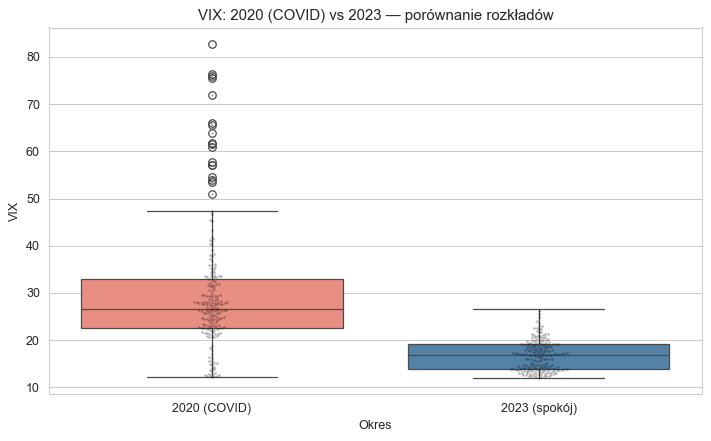

In [17]:
data_box = pd.DataFrame({
    'VIX':    np.concatenate([vix_2020, vix_2023]),
    'Okres':  ['2020 (COVID)']*len(vix_2020) + ['2023 (spokój)']*len(vix_2023)
})

plt.figure(figsize=(8, 5))
sns.boxplot(data=data_box, x='Okres', y='VIX', palette=['salmon','steelblue'])
sns.swarmplot(data=data_box.sample(min(400, len(data_box)), random_state=1),
              x='Okres', y='VIX', color='black', alpha=0.3, size=2)
plt.title('VIX: 2020 (COVID) vs 2023 — porównanie rozkładów')
plt.tight_layout(); plt.show()


## 6. Podsumowanie

| Krok | Wynik |
|---|---|
| Dataset | VIX dzienne 1990–2026 (9200+ obs.), źródło github.com/datasets/finance-vix |
| Okres analizy | ostatnie 5 lat (~1250 dni handlowych) |
| Średnie ruchome | MA(7) tygodniowa, MA(30) miesięczna — wygładzają sygnał |
| ACF/PACF na poziomie | wolny zanik ACF, dominujący PACF(1) → zachowanie AR(1) / I(1) |
| ACF/PACF na log-zwrotach | ≈ szum (EMH) |
| ADF test | poziom: stacjonarny na granicy (mean reversion); log-zwroty: stacjonarne ✓ |
| Dekompozycja | trend + sezonowość 5-dniowa + reszty; sezonowość nikła |
| Reszty | grube ogony (kurtoza ≫ 3) → niezbędny GARCH dla pełnego modelowania |
| Test t (2020 vs 2023) | p < 0.05 → istotna różnica (VIX znacznie wyższy w COVID) |
| Test Shapiro log-zwrotów | p < 0.05 → zwroty NIE są normalne (grube ogony) |

**Główne wnioski merytoryczne:**
1. **VIX wykazuje *mean reversion*** — nie ma trwałego trendu, oscyluje wokół średniej ~20.
2. **Klastrowanie zmienności** jest dominującą cechą — okresy spokoju przerywane gwałtownymi szokami.
3. **Sezonowość tygodniowa jest pomijalna** — VIX nie ma "kalendarzowego" rytmu jak np. sprzedaż detaliczna.
4. **Log-zwroty nie są normalne i nie są przewidywalne** — to fundamentalny fakt empiryczny rynków finansowych.
5. **Test t i test U dają zbieżne wnioski** — VIX w 2020 był istotnie wyższy niż w 2023, niezależnie od wybranego testu (parametryczny vs nieparametryczny).